In [25]:
import pandas as pd
import numpy as np

In [26]:
X_train = pd.read_csv('/content/X_train.csv')
X_val   = pd.read_csv('/content/X_val.csv')
X_test  = pd.read_csv('/content/X_test.csv')

y_train = pd.read_csv('/content/y_train.csv').squeeze()
y_val   = pd.read_csv('/content/y_val.csv').squeeze()
y_test  = pd.read_csv('/content/y_test.csv').squeeze()

print(X_train.shape, X_val.shape, X_test.shape)

(16416, 39) (2052, 39) (2053, 39)


In [27]:
X_train.dtypes

,0
hosts_time_as_host_years,float64
host_is_superhost,bool
neighbourhood_cleansed,object
neighbourhood_group_cleansed,object
latitude,float64
longitude,float64
property_type,object
room_type,object
accommodates,int64
bathrooms,float64


In [28]:
# filling remaining NaN in host_experience_level before encoding
X_train['host_experience_level'] = X_train['host_experience_level'].fillna('Experienced')
X_val['host_experience_level']   = X_val['host_experience_level'].fillna('Experienced')
X_test['host_experience_level']  = X_test['host_experience_level'].fillna('Experienced')

In [29]:
print(X_train['host_experience_level'].isnull().sum())

0


In [30]:
#doing encoding(i have refered to the book: hands on ml with pytorch by Aurelien geron)

#1. Changing bools to int
bool_cols = ['host_is_superhost', 'has_availability']
for col in bool_cols:
  X_train[col] = X_train[col].astype(int)
  X_val[col] = X_val[col].astype(int)
  X_test[col] = X_test[col].astype(int)

#2. for ordered categories like in host_exp level, we will use ordinalEncoder
from sklearn.preprocessing import OrdinalEncoder
ord_enc = OrdinalEncoder(categories=[['New', 'Intermediate', 'Experienced']])
X_train['host_experience_level'] = ord_enc.fit_transform(X_train[['host_experience_level']])
X_val['host_experience_level']   = ord_enc.transform(X_val[['host_experience_level']])
X_test['host_experience_level']  = ord_enc.transform(X_test[['host_experience_level']])

#3. for columns with no natural order, we will use OneHotEncoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

one_cols = ['room_type', 'neighbourhood_group_cleansed', 'property_type']
one_enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_train = pd.DataFrame(one_enc.fit_transform(X_train[one_cols]),
                         columns=one_enc.get_feature_names_out(one_cols),
                         index=X_train.index)

ohe_val = pd.DataFrame(one_enc.transform(X_val[one_cols]),
                       columns=one_enc.get_feature_names_out(one_cols),
                       index=X_val.index)

ohe_test = pd.DataFrame(one_enc.transform(X_test[one_cols]),
                        columns=one_enc.get_feature_names_out(one_cols),
                        index=X_test.index)

X_train = pd.concat([X_train.drop(columns=one_cols), ohe_train], axis=1)
X_val   = pd.concat([X_val.drop(columns=one_cols), ohe_val], axis=1)
X_test  = pd.concat([X_test.drop(columns=one_cols), ohe_test], axis=1)

#4. on page (97-98) in my book, it says in the tips section that applying OHE on large amout of input features will slow the system down
#   so its better to replace categorial features with numerical features.
#   and neighbourhood_cleansed has 200+ unique nighbourhoods, so OHE would create 200+ diff input features.
#   so i am going to replace that with mean log_price of that neighbourhood (from train set)

neigh_means = X_train.copy()
neigh_means['log_price'] = y_train.values
neigh_means = neigh_means.groupby('neighbourhood_cleansed')['log_price'].mean()

global_mean = y_train.mean()

X_train['neighbourhood_cleansed'] = X_train['neighbourhood_cleansed'].map(neigh_means).fillna(global_mean)
X_val['neighbourhood_cleansed'] = X_val['neighbourhood_cleansed'].map(neigh_means).fillna(global_mean)
X_test['neighbourhood_cleansed'] = X_test['neighbourhood_cleansed'].map(neigh_means).fillna(global_mean)

In [31]:
#scaling (Done after encoding)

from sklearn.preprocessing import RobustScaler

scale_cols = ['hosts_time_as_host_years', 'accommodates', 'bathrooms', 'bedrooms',
              'maximum_nights', 'maximum_nights_avg_ntm', 'number_of_reviews',
              'estimated_occupancy_l365d', 'days_since_first_review',
              'days_since_last_review', 'calculated_host_listings_count',
              'amenity_count', 'availability_rate', 'total_availability_score',
              'review_scores_cleanliness', 'review_scores_location',
              'review_score_avg', 'neighbourhood_cleansed']

scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

Writing the models

In [32]:
#1. Ridge (baseline model)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

baseline = Ridge(alpha=1.0)
baseline.fit(X_train, y_train)

val_preds = baseline.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, val_preds))
r2 = r2_score(y_val, val_preds)

print(f"Ridge baseline - RMSE: {rmse:.4f}, R²: {r2:.4f}")

val_preds_dollars = np.expm1(val_preds)
y_val_dollars = np.expm1(y_val)
dollar_rmse = np.sqrt(mean_squared_error(y_val_dollars, val_preds_dollars))
print(f"Average prediction error: ${dollar_rmse:.2f}")

Ridge baseline - RMSE: 0.4931, R²: 0.6130
Average prediction error: $246.22


In [33]:
#2. Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth = 15, min_samples_leaf = 5, random_state=42, n_jobs = -1)

rf.fit(X_train, y_train)

val_preds_rf = rf.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, val_preds_rf))
r2_rf = r2_score(y_val, val_preds_rf)

print(f"Random Forest - RMSE: {rmse_rf:.4f}, R²: {r2_rf:.4f}")

Random Forest - RMSE: 0.4207, R²: 0.7183


In [34]:
#3. XGBoost

from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose = 50)

val_preds_xgb = xgb.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, val_preds_xgb))
r2_xgb = r2_score(y_val, val_preds_xgb)
print(f"XGBoost - RMSE: {rmse_xgb:.4f}, R²: {r2_xgb:.4f}")

[0]	validation_0-rmse:0.76979
[50]	validation_0-rmse:0.43935
[100]	validation_0-rmse:0.41265
[150]	validation_0-rmse:0.40079
[200]	validation_0-rmse:0.39454
[250]	validation_0-rmse:0.38971
[300]	validation_0-rmse:0.38617
[350]	validation_0-rmse:0.38455
[400]	validation_0-rmse:0.38313
[450]	validation_0-rmse:0.38212
[499]	validation_0-rmse:0.38072
XGBoost - RMSE: 0.3807, R²: 0.7693


In [35]:
#comparing models and picking the best
results = pd.DataFrame({
    'Model': ['Ridge Baseline', 'Random Forest', 'XGBoost'],
    'Val RMSE': [rmse, rmse_rf, rmse_xgb],
    'Val R²':   [r2, r2_rf, r2_xgb]
})
print(results.sort_values('Val RMSE'))


            Model  Val RMSE    Val R²
2         XGBoost  0.380721  0.769292
1   Random Forest  0.420699  0.718296
0  Ridge Baseline  0.493120  0.612960


In [36]:
print(X_train.shape)
print(X_train.dtypes.value_counts())
print(X_train.isnull().sum().sum())

(16416, 93)
float64    78
int64      15
Name: count, dtype: int64
0


In [37]:
# dollar error for all three models
for name, preds in [('Ridge', val_preds), ('Random Forest', val_preds_rf), ('XGBoost', val_preds_xgb)]:
    dollar_rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(preds)))
    print(f"{name}: ${dollar_rmse:.2f} average error")

Ridge: $246.22 average error
Random Forest: $246.32 average error
XGBoost: $212.85 average error


In [38]:
test_preds = xgb.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2   = r2_score(y_test, test_preds)
print(f"FINAL TEST — RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")

test_dollar_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_preds)))
print(f"Average prediction error: ${test_dollar_rmse:.2f}")

FINAL TEST — RMSE: 0.3829, R²: 0.7611
Average prediction error: $188.93


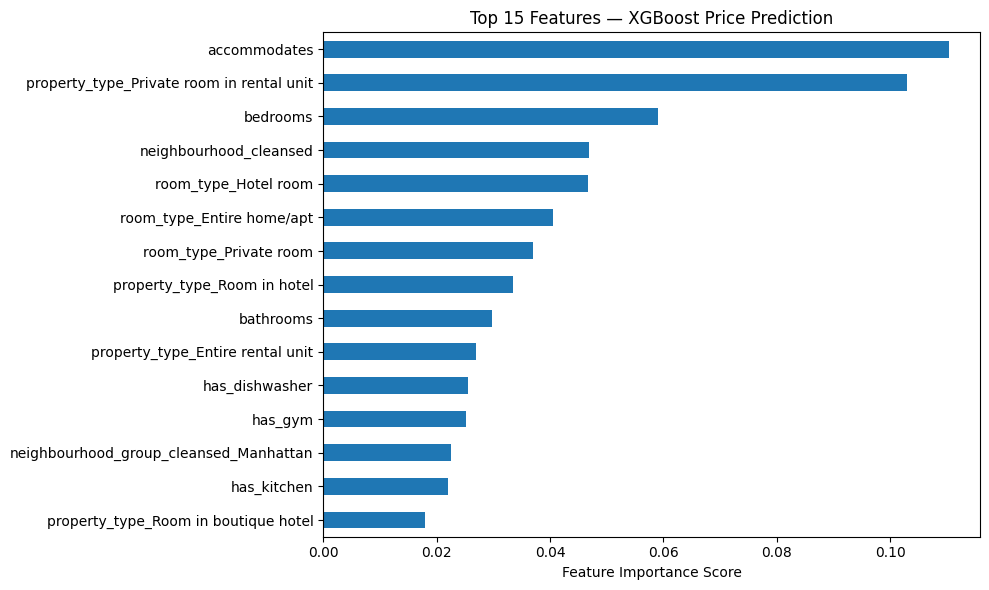

In [39]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Features — XGBoost Price Prediction')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [40]:
import joblib
joblib.dump(xgb, 'xgboost_airbnb_model.pkl')

['xgboost_airbnb_model.pkl']

In [41]:
from google.colab import files
files.download('xgboost_airbnb_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

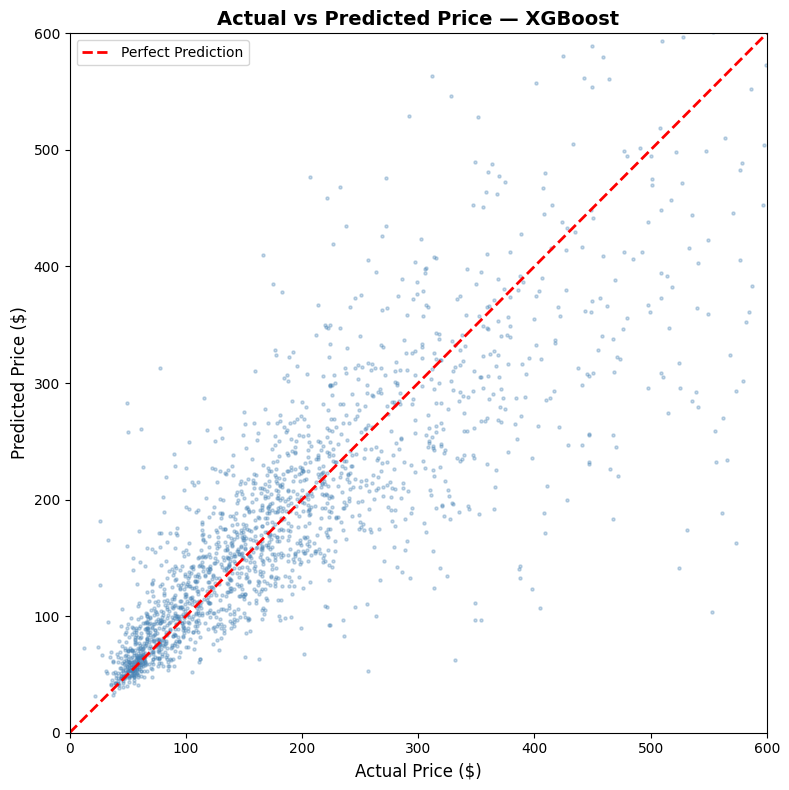

In [42]:
# Plot 6: Actual vs Predicted
import matplotlib.pyplot as plt
import numpy as np

actual_dollars = np.expm1(y_test)
pred_dollars   = np.expm1(test_preds)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(actual_dollars, pred_dollars, alpha=0.3, s=5, color='steelblue')
ax.plot([0, 600], [0, 600], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price ($)', fontsize=12)
ax.set_ylabel('Predicted Price ($)', fontsize=12)
ax.set_title('Actual vs Predicted Price — XGBoost', fontsize=14, fontweight='bold')
ax.set_xlim(0, 600)
ax.set_ylim(0, 600)
ax.legend()
plt.tight_layout()
plt.savefig('06_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
test_preds = xgb.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)
test_dollar = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_preds)))
print(f"FINAL TEST — R²: {test_r2:.4f}, Error: ${test_dollar:.2f}")

FINAL TEST — R²: 0.7611, Error: $188.93
